# Detecting housing bubbles on the danish housing market

This project is trying to detect if there are any explosive behaviour on the danish housing market, from 1998 first quarter, to 2023 fourth quarter. 

The idea of the project is to test the real danish housing prices for unite roots. The procedure used is the BSADF test, wich is introduced in Philips (2011). The difference from the classical is there in a BSADF test is a flexible window width. 

In [2]:
#importing packages
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In this section we load our data, and mark that the data is quarterly data

In [3]:
file_path = 'Huspris_kvartal.xlsx'
df = pd.read_excel(file_path)

df['Year'] = df['Period'].str.extract('(\d{4})')
df['Quarter'] = df['Period'].str.extract('q(\d)')

# Convert to datetime and set as index
df['Period'] = pd.to_datetime(df['Year'] + df['Quarter'], format='%Y%m')
df.set_index('Period', inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: 'Huspris kvartal.xlsx'

In this section we plot the real house prices for single family houses in the region of Copenhagen.

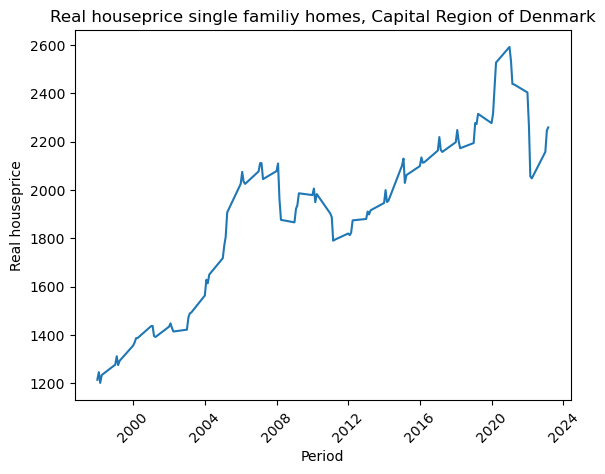

In [ ]:
# Plotting the values of the column RHP_EFHL
price = df['RHP_EFHL']
plt.plot(df.index, price)
plt.title('Real houseprice single familiy homes, Capital Region of Denmark') 
plt.xlabel('Period')
plt.ylabel('Real houseprice')
plt.xticks(rotation=45)
plt.show()

Looking at the raw data from Copenhagen, there is immediately a explovsive growth in the house prices in the periode of 2005-2008 and again in 2020-2021.

DatetimeIndex(['2004-02-01', '2004-03-01', '2004-04-01', '2005-01-01',
               '2005-02-01', '2005-03-01', '2005-04-01', '2006-01-01',
               '2006-02-01', '2006-03-01', '2006-04-01', '2014-03-01',
               '2020-04-01', '2021-01-01', '2021-02-01', '2022-03-01',
               '2022-04-01'],
              dtype='datetime64[ns]', name='Period', freq=None)


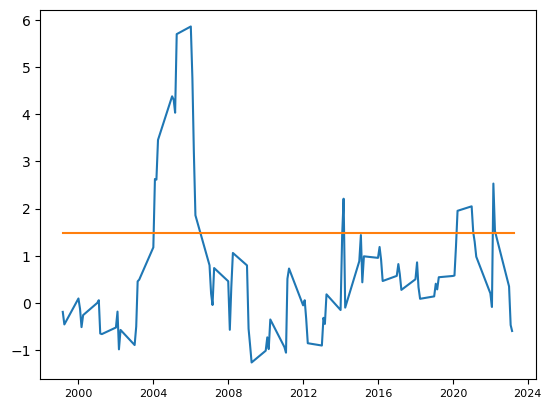

In [ ]:
#this is a bubble detecting algorithm developed by Phillips and Yu (2011) and Phillips et al. (2015) 
#it is based on the augmented Dickey-Fuller test and is used to detect bubbles in financial data.

# Generate price variable
prices = df['RHP_EFRH']

# Inputting the parameters
r0 = int(len(prices) * 0.05)
adf_lags = 1
crit = 1.49
#transforming data
log_prices = np.array(np.log(prices))
delta_log_prices = log_prices[1:] - log_prices[:-1]
n = len(delta_log_prices)
BSADF = np.array([])
#calculating ADF stats
for r2 in range(r0,n):
    ADFS = np.array([])
    for r1 in range(0,r2-r0+1):
        X0 = log_prices[r1:r2+1]
        X = pd.DataFrame()
        X[0] = X0
        for j in range(1,adf_lags+1):
            X[j] = np.append(np.zeros(j),delta_log_prices[r1:r2+1-j])
        X = np.array(X)
        Y = delta_log_prices[r1:r2+1]
        reg = sm.OLS(Y,sm.add_constant(X))
        res = reg.fit()
        ADFS = np.append(ADFS, res.params[1]/res.bse[1])
    BSADF = np.append(BSADF, max(ADFS))
#visualising the results
plt.rc('xtick',labelsize = 8)
plt.plot(prices.index[r0+1:],BSADF)
plt.plot(prices.index[r0+1:],np.ones(len(BSADF))*crit)
#printing dates when bubbles were detected
print(prices.index[r0+1:][BSADF > crit])

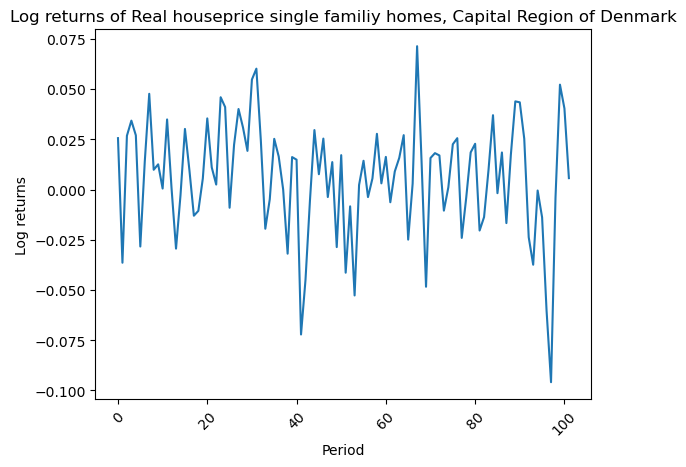

Iteration:      1,   Func. Count:      6,   Neg. LLF: 3926681.659348047
Iteration:      2,   Func. Count:     16,   Neg. LLF: 640.263896486822
Iteration:      3,   Func. Count:     23,   Neg. LLF: -210.82715661158622
Iteration:      4,   Func. Count:     30,   Neg. LLF: -222.15018972778452
Iteration:      5,   Func. Count:     36,   Neg. LLF: -206.98551069298998
Iteration:      6,   Func. Count:     43,   Neg. LLF: -222.64985901554567
Iteration:      7,   Func. Count:     50,   Neg. LLF: -222.74035294345342
Iteration:      8,   Func. Count:     55,   Neg. LLF: -222.74038157799822
Iteration:      9,   Func. Count:     59,   Neg. LLF: -222.74038157798174
Optimization terminated successfully    (Exit mode 0)
            Current function value: -222.74038157799822
            Iterations: 9
            Function evaluations: 59
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:               RHP_EFHL   R-squared: 

/var/folders/sv/y0_gb2yj6zxb__6rrppst5b80000gn/T/ipykernel_24225/1753265942.py:28: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  log_returns = prices.pct_change().dropna()
/Users/magnusfriischristiansen/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.000793. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [4]:
import arch
from arch import arch_model

file_path = 'Huspris_kvartal.xlsx'
df = pd.read_excel(file_path)
price= df['RHP_EFHL']
log_prices = np.array(np.log(price))
delta_log_prices = log_prices[1:] - log_prices[:-1]
plt.plot(delta_log_prices)
plt.title('Log returns of Real houseprice single familiy homes, Capital Region of Denmark')
plt.xlabel('Period')
plt.ylabel('Log returns')
plt.xticks(rotation=45)
plt.show()

# Extract year and quarter separately
df['Year'] = df['Period'].str.extract('(\d{4})')
df['Quarter'] = df['Period'].str.extract('q(\d)')

# Convert to datetime and set as index
df['Period'] = pd.to_datetime(df['Year'] + df['Quarter'], format='%Y%m')
df.set_index('Period', inplace=True)

# Generate price variable
prices = df['RHP_EFHL']

# Compute log returns
log_returns = prices.pct_change().dropna()

# Build GARCH(1,1) model
garch_model = arch_model(log_returns, vol='Garch', p=1, q=1)

# Fit the model
garch_result = garch_model.fit()

# Print model summary
print(garch_result.summary())
